Libaraies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


Data Loading

In [14]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully:", file_name)
print("Initial Shape:", df.shape)
df.head()

Saving advertising.csv to advertising (1).csv
Dataset loaded successfully: advertising (1).csv
Initial Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Data Checking & Cleaning

In [3]:
df.columns = df.columns.str.strip()

drop_cols = [col for col in df.columns if 'unnamed' in col.lower()]
if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f"Dropped redundant index column: {drop_cols}")

print("\n--- MISSING VALUE CHECK ---")
print(df.isnull().sum())

print("\nDuplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nCleaned Dataset Shape:", df.shape)
print("\nDescriptive Summary:")
display(df.describe().round(2))


--- MISSING VALUE CHECK ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows found: 0

Cleaned Dataset Shape: (200, 4)

Descriptive Summary:


,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,15.13
std,85.85,14.85,21.78,5.28
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,11.00
50%,149.75,22.90,25.75,16.00
75%,218.82,36.52,45.10,19.05
max,296.40,49.60,114.00,27.00


Feature Engineering

In [5]:
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']

df['TV_Share'] = (df['TV'] / df['Total_Spend']).round(4)
df['Radio_Share'] = (df['Radio'] / df['Total_Spend']).round(4)
df['Newspaper_Share'] = (df['Newspaper'] / df['Total_Spend']).round(4)

corr_matrix = df[['TV', 'Radio', 'Newspaper', 'Total_Spend', 'Sales']].corr()

print("--- CORRELATION WITH SALES ---")
print(corr_matrix['Sales'].sort_values(ascending=False).round(4))


--- CORRELATION WITH SALES ---
Sales          1.0000
Total_Spend    0.9249
TV             0.9012
Radio          0.3496
Newspaper      0.1580
Name: Sales, dtype: float64


Correalation

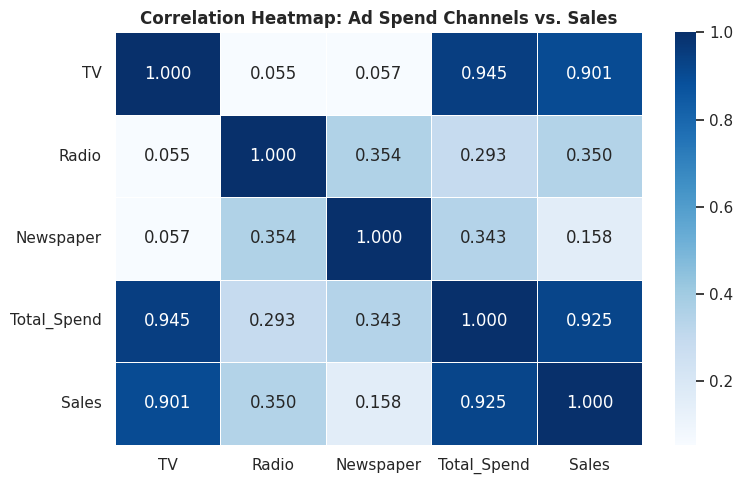

In [6]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".3f", linewidths=0.5)
plt.title("Correlation Heatmap: Ad Spend Channels vs. Sales", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

Model Training

In [16]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression (OLS)": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

benchmark_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    benchmark_results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4)
    })

eval_df = pd.DataFrame(benchmark_results)
display(eval_df)

from IPython.display import display

print("--- MODEL RESULTS ---")
print(eval_df.to_string(index=False))

,Model,R2 Score,MAE,RMSE
0,Linear Regression (OLS),0.9059,1.2748,1.7052
1,Ridge Regression,0.9059,1.2748,1.7052
2,Random Forest Regressor,0.9535,0.9180,1.1989


--- MODEL RESULTS ---
                  Model  R2 Score    MAE   RMSE
Linear Regression (OLS)    0.9059 1.2748 1.7052
       Ridge Regression    0.9059 1.2748 1.7052
Random Forest Regressor    0.9535 0.9180 1.1989


Visualization

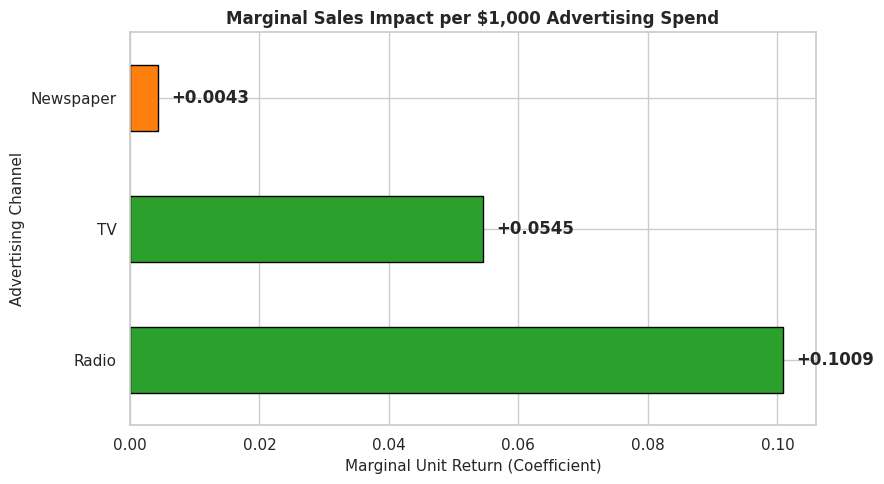

--- MARGINAL IMPACT BREAKDOWN ---
Base Sales without Advertising (Intercept): 4.714
Every $1,000 spent on TV         yields approximately 54.5 incremental units.
Every $1,000 spent on Radio      yields approximately 100.9 incremental units.
Every $1,000 spent on Newspaper  yields approximately 4.3 incremental units.


In [12]:
lr = models["Linear Regression (OLS)"]
coefficients = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = [
    "#2ca02c" if c > 0.05 else "#ff7f0e" if c > 0 else "#d62728"
    for c in coefficients
]
coefficients.plot(kind="barh", color=colors, edgecolor="black")

plt.title(
    "Marginal Sales Impact per $1,000 Advertising Spend",
    fontsize=12,
    weight="bold",
)
plt.xlabel("Marginal Unit Return (Coefficient)", fontsize=11)
plt.ylabel("Advertising Channel", fontsize=11)

for i, v in enumerate(coefficients):
  plt.text(
      v + 0.002, i, f"+{v:.4f}" if v >= 0 else f"{v:.4f}", va="center", weight="bold"
  )

plt.tight_layout()
plt.show()

print("--- MARGINAL IMPACT BREAKDOWN ---")
print(f"Base Sales without Advertising (Intercept): {lr.intercept_:.3f}")
for col, coef in zip(X.columns, lr.coef_):
  print(
      f"Every $1,000 spent on {col:<10} yields approximately {coef * 1000:.1f} incremental units."
  )

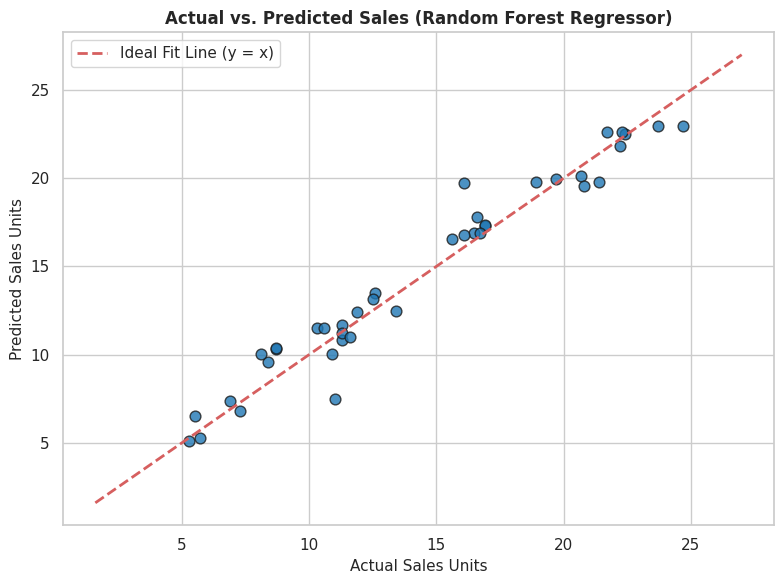

In [13]:
rf = models["Random Forest Regressor"]
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color="#1f77b4", edgecolors="k", alpha=0.8, s=60)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "--r",
    lw=2,
    label="Ideal Fit Line (y = x)",
)

plt.title(
    "Actual vs. Predicted Sales (Random Forest Regressor)",
    fontsize=12,
    weight="bold",
)
plt.xlabel("Actual Sales Units", fontsize=11)
plt.ylabel("Predicted Sales Units", fontsize=11)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()